# Regresión Lineal Simple y Múltiple — DATA-DOGS

**Target**: `vida_promedio` (años de vida esperada de la raza)

**Fundamento biológico**: La ley alométrica establece que los mamíferos de mayor masa corporal tienen metabolismos más lentos pero viven menos tiempo en el caso de los perros domésticos (inversamente a la tendencia interespecífica). Razas gigantes como el Dogo Argentino (60 kg, ~10 años) vs razas toy como el Chihuahua (3 kg, ~15 años).

**Predictores seleccionados**:
- **Simple**: `log(peso_promedio)` — linealiza la relación alométrica
- **Múltiple**: `log(peso_promedio)` + `diferencia_sexual_peso` + `hipoalergenico`

**Excluidos**:
- `vida_min`, `vida_max`: componentes directos de `vida_promedio` (colinealidad perfecta)
- `peso_macho_max`, `peso_hembra_max`: componentes de `peso_promedio` (colinealidad directa)
- `categoria_peso`: derivada de `peso_promedio` (redundante)

**Herramientas**: `statsmodels` para OLS + diagnósticos estadísticos | `sklearn` para splits y CV

In [ ]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor, OLSInfluence

warnings.filterwarnings('ignore')
os.makedirs('../data/graficas', exist_ok=True)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

RANDOM_STATE = 42
print('✓ Librerías cargadas')

✓ Librerías cargadas


In [ ]:
df = pd.read_csv('../data/dogs_normalized.csv')
df['log_peso'] = np.log(df['peso_promedio'])
df['hipoalergenico'] = df['hipoalergenico'].astype(int)

print(f'Dataset: {df.shape[0]} razas x {df.shape[1]} columnas')
print(f'Nulos: {df.isnull().sum().sum()}')
display(df[['raza', 'vida_promedio', 'peso_promedio', 'log_peso', 'diferencia_sexual_peso', 'hipoalergenico']].describe().round(3))

Dataset: 283 razas x 12 columnas
Nulos: 0


,vida_promedio,peso_promedio,log_peso,diferencia_sexual_peso,hipoalergenico
count,283.000,283.000,283.000,283.000,283.000
mean,13.007,26.611,2.997,1.046,0.046
std,1.429,19.733,0.803,3.014,0.210
min,7.000,3.000,1.099,0.000,0.000
25%,13.000,11.000,2.398,0.000,0.000
50%,13.000,25.000,3.219,0.000,0.000
75%,13.500,32.000,3.466,0.000,0.000
max,17.500,110.000,4.700,20.000,1.000


---
## Fase 1 — Análisis Exploratorio para Regresión

Verificamos los supuestos previos al modelado: distribución del target, distribución del predictor principal, y naturaleza de las relaciones lineales.

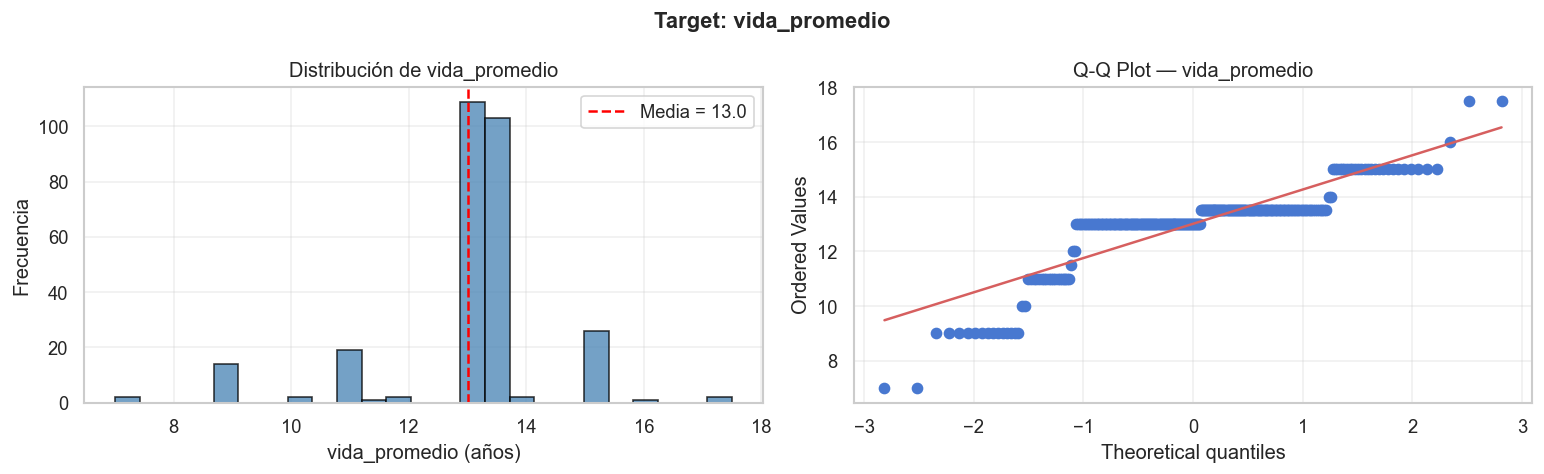

Shapiro-Wilk sobre vida_promedio: W=0.7633, p=0.0000
→ Desviación de la normalidad (p < 0.05) — aceptable para n=283


In [ ]:
# --- 1.1 Distribución del target: vida_promedio ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['vida_promedio'], bins=25, edgecolor='black', alpha=0.75, color='steelblue')
axes[0].axvline(df['vida_promedio'].mean(), color='red', linestyle='--', label=f"Media = {df['vida_promedio'].mean():.1f}")
axes[0].set_xlabel('vida_promedio (años)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de vida_promedio')
axes[0].legend()
axes[0].grid(alpha=0.3)

stats.probplot(df['vida_promedio'], dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot — vida_promedio')
axes[1].grid(alpha=0.3)

plt.suptitle('Target: vida_promedio', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/graficas/eda_target_distribucion.png', dpi=150, bbox_inches='tight')
plt.show()

stat_sw, p_sw = stats.shapiro(df['vida_promedio'])
print(f'Shapiro-Wilk sobre vida_promedio: W={stat_sw:.4f}, p={p_sw:.4f}')
print('→ Distribución aproximadamente normal' if p_sw > 0.05 else '→ Desviación de la normalidad (p < 0.05) — aceptable para n=283')

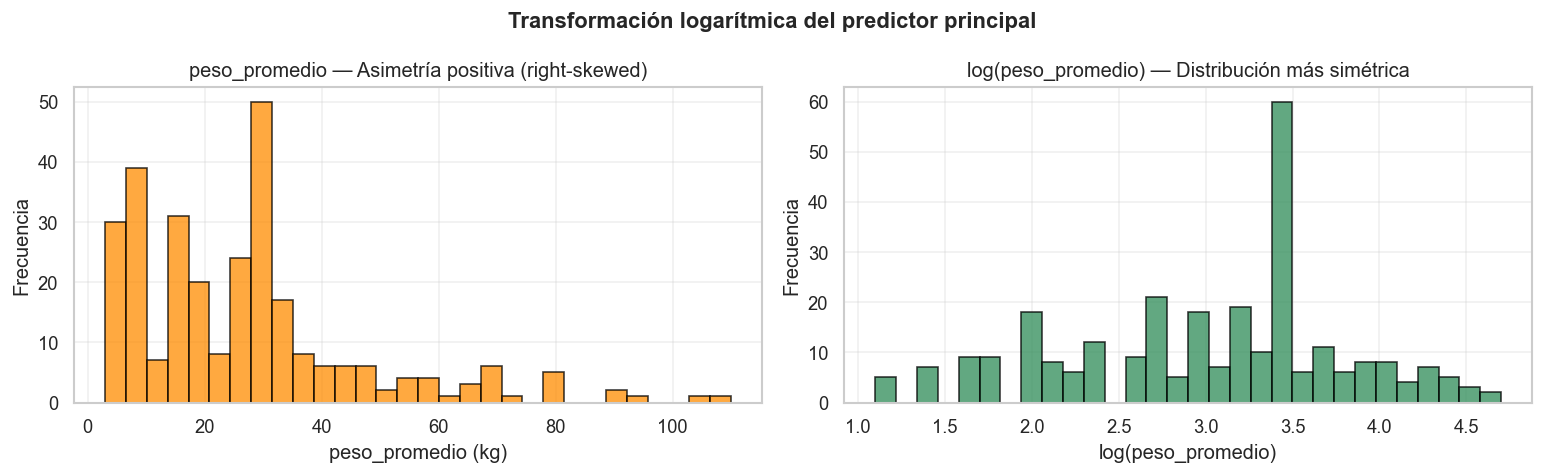

Asimetría peso_promedio:  1.475
Asimetría log_peso:       -0.393
→ La transformación log reduce la asimetría y estabiliza la varianza.


In [ ]:
# --- 1.2 peso_promedio (raw) vs log(peso_promedio): justificación de la transformación ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['peso_promedio'], bins=30, edgecolor='black', alpha=0.75, color='darkorange')
axes[0].set_xlabel('peso_promedio (kg)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('peso_promedio — Asimetría positiva (right-skewed)')
axes[0].grid(alpha=0.3)

axes[1].hist(df['log_peso'], bins=30, edgecolor='black', alpha=0.75, color='seagreen')
axes[1].set_xlabel('log(peso_promedio)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('log(peso_promedio) — Distribución más simétrica')
axes[1].grid(alpha=0.3)

plt.suptitle('Transformación logarítmica del predictor principal', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/graficas/eda_peso_transformacion.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Asimetría peso_promedio:  {df["peso_promedio"].skew():.3f}')
print(f'Asimetría log_peso:       {df["log_peso"].skew():.3f}')
print('→ La transformación log reduce la asimetría y estabiliza la varianza.')

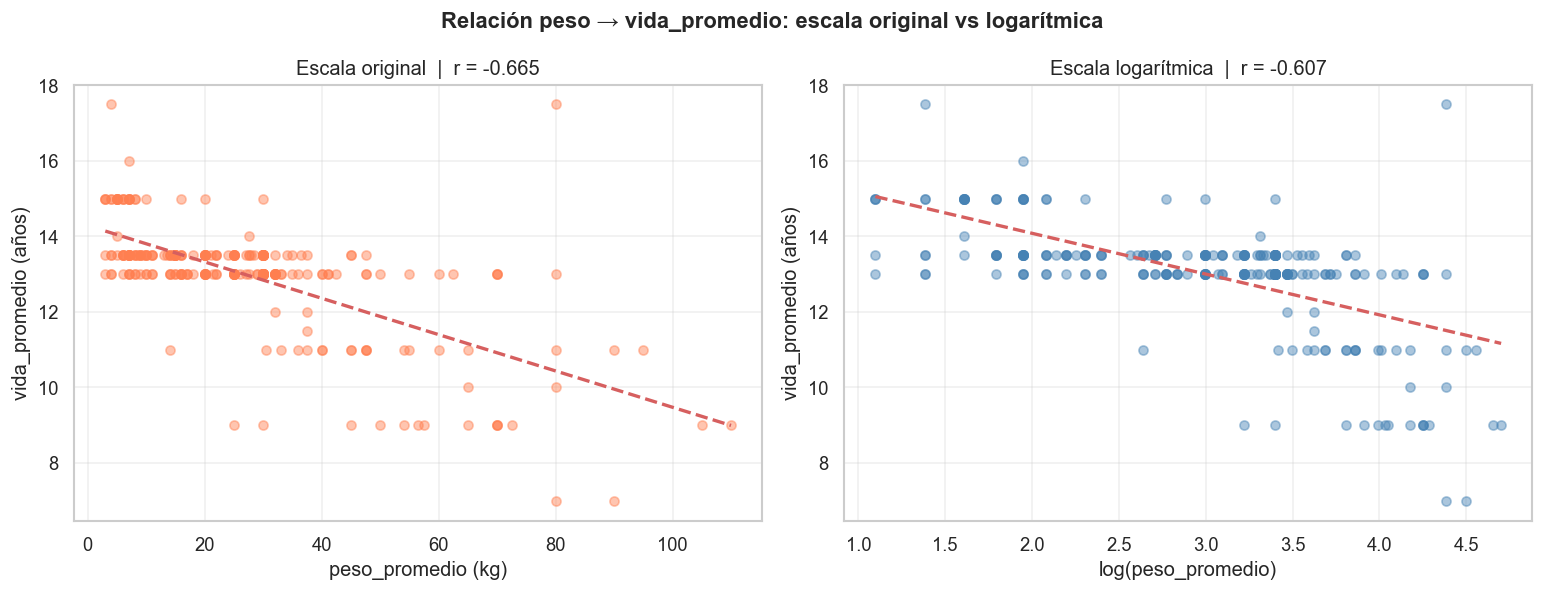

Correlación de Pearson (peso raw):  r = -0.6648
Correlación de Pearson (log_peso):  r = -0.6072
→ Mayor correlación lineal absoluta con vida_promedio: peso raw
→ Se usa log(peso) porque linealiza la escala alométrica y reduce la asimetría del predictor,
  mejorando el cumplimiento de supuestos OLS (homoscedasticidad, distribución de residuos).


In [ ]:
# --- 1.3 Linealidad: vida_promedio vs peso (raw) y vs log(peso) ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(df['peso_promedio'], df['vida_promedio'], alpha=0.45, s=30, color='coral')
m, b = np.polyfit(df['peso_promedio'], df['vida_promedio'], 1)
x_line = np.linspace(df['peso_promedio'].min(), df['peso_promedio'].max(), 200)
axes[0].plot(x_line, m * x_line + b, 'r--', lw=2)
r_raw = df['peso_promedio'].corr(df['vida_promedio'])
axes[0].set_xlabel('peso_promedio (kg)')
axes[0].set_ylabel('vida_promedio (años)')
axes[0].set_title(f'Escala original  |  r = {r_raw:.3f}')
axes[0].grid(alpha=0.3)

axes[1].scatter(df['log_peso'], df['vida_promedio'], alpha=0.45, s=30, color='steelblue')
m2, b2 = np.polyfit(df['log_peso'], df['vida_promedio'], 1)
x_line2 = np.linspace(df['log_peso'].min(), df['log_peso'].max(), 200)
axes[1].plot(x_line2, m2 * x_line2 + b2, 'r--', lw=2)
r_log = df['log_peso'].corr(df['vida_promedio'])
axes[1].set_xlabel('log(peso_promedio)')
axes[1].set_ylabel('vida_promedio (años)')
axes[1].set_title(f'Escala logarítmica  |  r = {r_log:.3f}')
axes[1].grid(alpha=0.3)

plt.suptitle('Relación peso → vida_promedio: escala original vs logarítmica', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/graficas/eda_scatter_linealidad.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Correlación de Pearson (peso raw):  r = {r_raw:.4f}')
print(f'Correlación de Pearson (log_peso):  r = {r_log:.4f}')
mejor = 'log(peso)' if abs(r_log) >= abs(r_raw) else 'peso raw'
print(f'→ Mayor correlación lineal absoluta con vida_promedio: {mejor}')
print('→ Se usa log(peso) porque linealiza la escala alométrica y reduce la asimetría del predictor,')
print('  mejorando el cumplimiento de supuestos OLS (homoscedasticidad, distribución de residuos).')

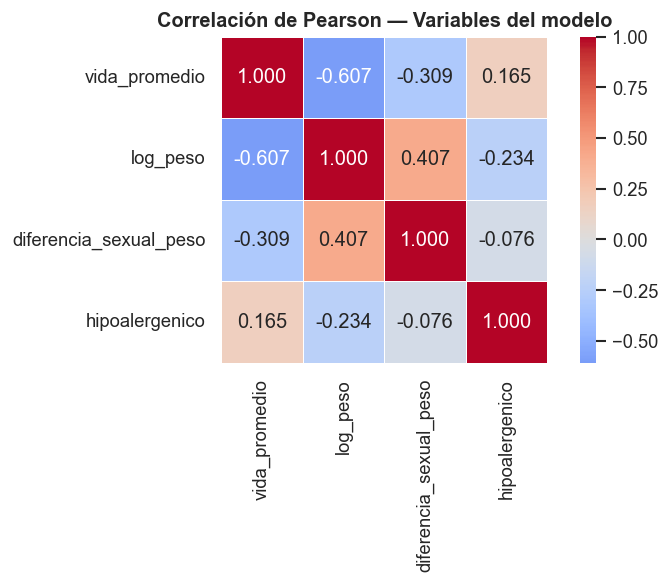

log_peso                 -0.607232
diferencia_sexual_peso   -0.309297
hipoalergenico            0.164623
Name: vida_promedio, dtype: float64


In [ ]:
# --- 1.4 Matriz de correlación de Pearson entre variables candidatas ---
cols_corr = ['vida_promedio', 'log_peso', 'diferencia_sexual_peso', 'hipoalergenico']
corr_matrix = df[cols_corr].corr()

plt.figure(figsize=(7, 5))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True, annot_kws={'size': 12})
plt.title('Correlación de Pearson — Variables del modelo', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/graficas/eda_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

print(corr_matrix['vida_promedio'].drop('vida_promedio').sort_values())

---
## Fase 2 — Regresión Lineal Simple

**Modelo**: `vida_promedio ~ β₀ + β₁ · log(peso_promedio) + ε`

Se usa `statsmodels.OLS` para obtener coeficientes, p-values, intervalos de confianza y métricas de ajuste.
Se verifican los 4 supuestos clásicos de la regresión OLS: linealidad, homoscedasticidad, normalidad de residuos e independencia.

In [ ]:
# --- 2.1 Modelo OLS simple: vida_promedio ~ log(peso_promedio) ---
X_simple = sm.add_constant(df['log_peso'])
y = df['vida_promedio']

ols_simple = sm.OLS(y, X_simple).fit()
print(ols_simple.summary())

                            OLS Regression Results                            
Dep. Variable:          vida_promedio   R-squared:                       0.369
Model:                            OLS   Adj. R-squared:                  0.366
Method:                 Least Squares   F-statistic:                     164.1
Date:                Tue, 21 Apr 2026   Prob (F-statistic):           6.63e-30
Time:                        16:16:05   Log-Likelihood:                -436.90
No. Observations:                 283   AIC:                             877.8
Df Residuals:                     281   BIC:                             885.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         16.2455      0.262     62.087      0.0

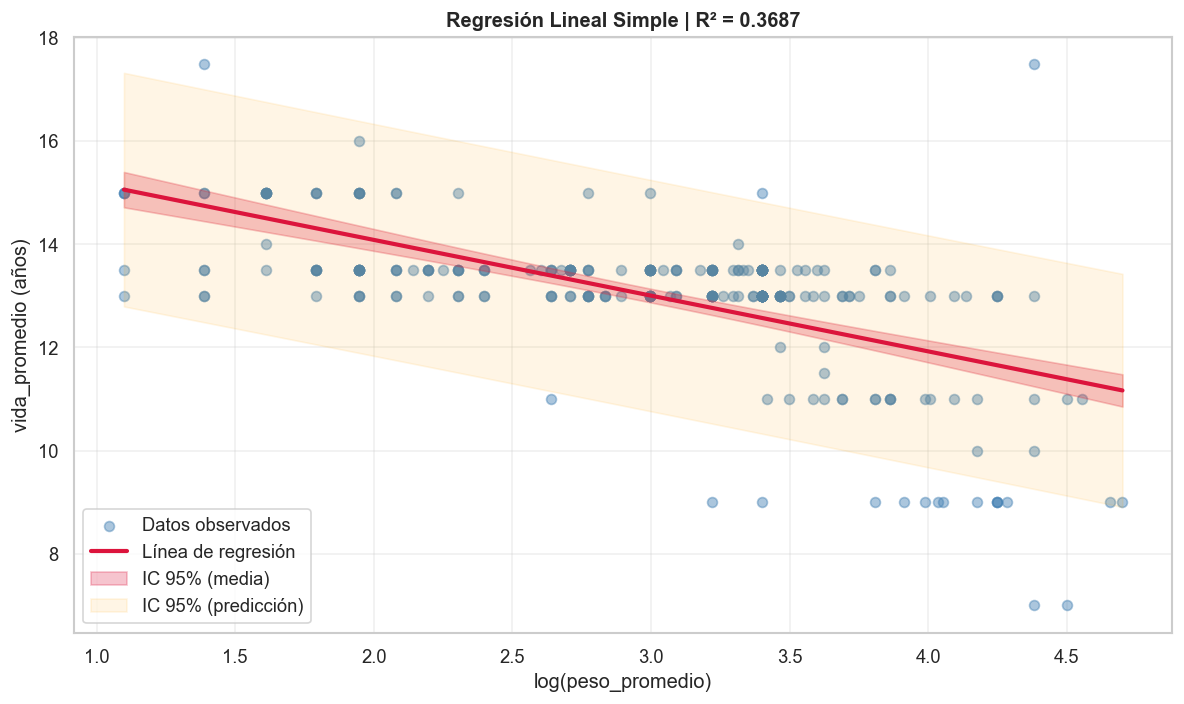


Ecuación: vida_promedio = 16.2455 + (-1.0805) · log(peso_promedio)
Interpretación: por cada unidad que aumenta log(peso), la vida esperada cambia -1.080 años.


In [ ]:
# --- 2.2 Gráfica: línea de regresión + banda de confianza 95% ---
x_sorted = df['log_peso'].sort_values()
X_sorted = sm.add_constant(x_sorted)
pred_sorted = ols_simple.get_prediction(X_sorted).summary_frame(alpha=0.05)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df['log_peso'], df['vida_promedio'], alpha=0.45, s=35, color='steelblue', label='Datos observados')
ax.plot(x_sorted, pred_sorted['mean'], color='crimson', lw=2.5, label='Línea de regresión')
ax.fill_between(x_sorted, pred_sorted['mean_ci_lower'], pred_sorted['mean_ci_upper'],
                alpha=0.25, color='crimson', label='IC 95% (media)')
ax.fill_between(x_sorted, pred_sorted['obs_ci_lower'], pred_sorted['obs_ci_upper'],
                alpha=0.10, color='orange', label='IC 95% (predicción)')
ax.set_xlabel('log(peso_promedio)')
ax.set_ylabel('vida_promedio (años)')
ax.set_title(f'Regresión Lineal Simple | R² = {ols_simple.rsquared:.4f}', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../data/graficas/simple_regresion_linea.png', dpi=150, bbox_inches='tight')
plt.show()

b0, b1 = ols_simple.params['const'], ols_simple.params['log_peso']
print(f'\nEcuación: vida_promedio = {b0:.4f} + ({b1:.4f}) · log(peso_promedio)')
print(f'Interpretación: por cada unidad que aumenta log(peso), la vida esperada cambia {b1:.3f} años.')

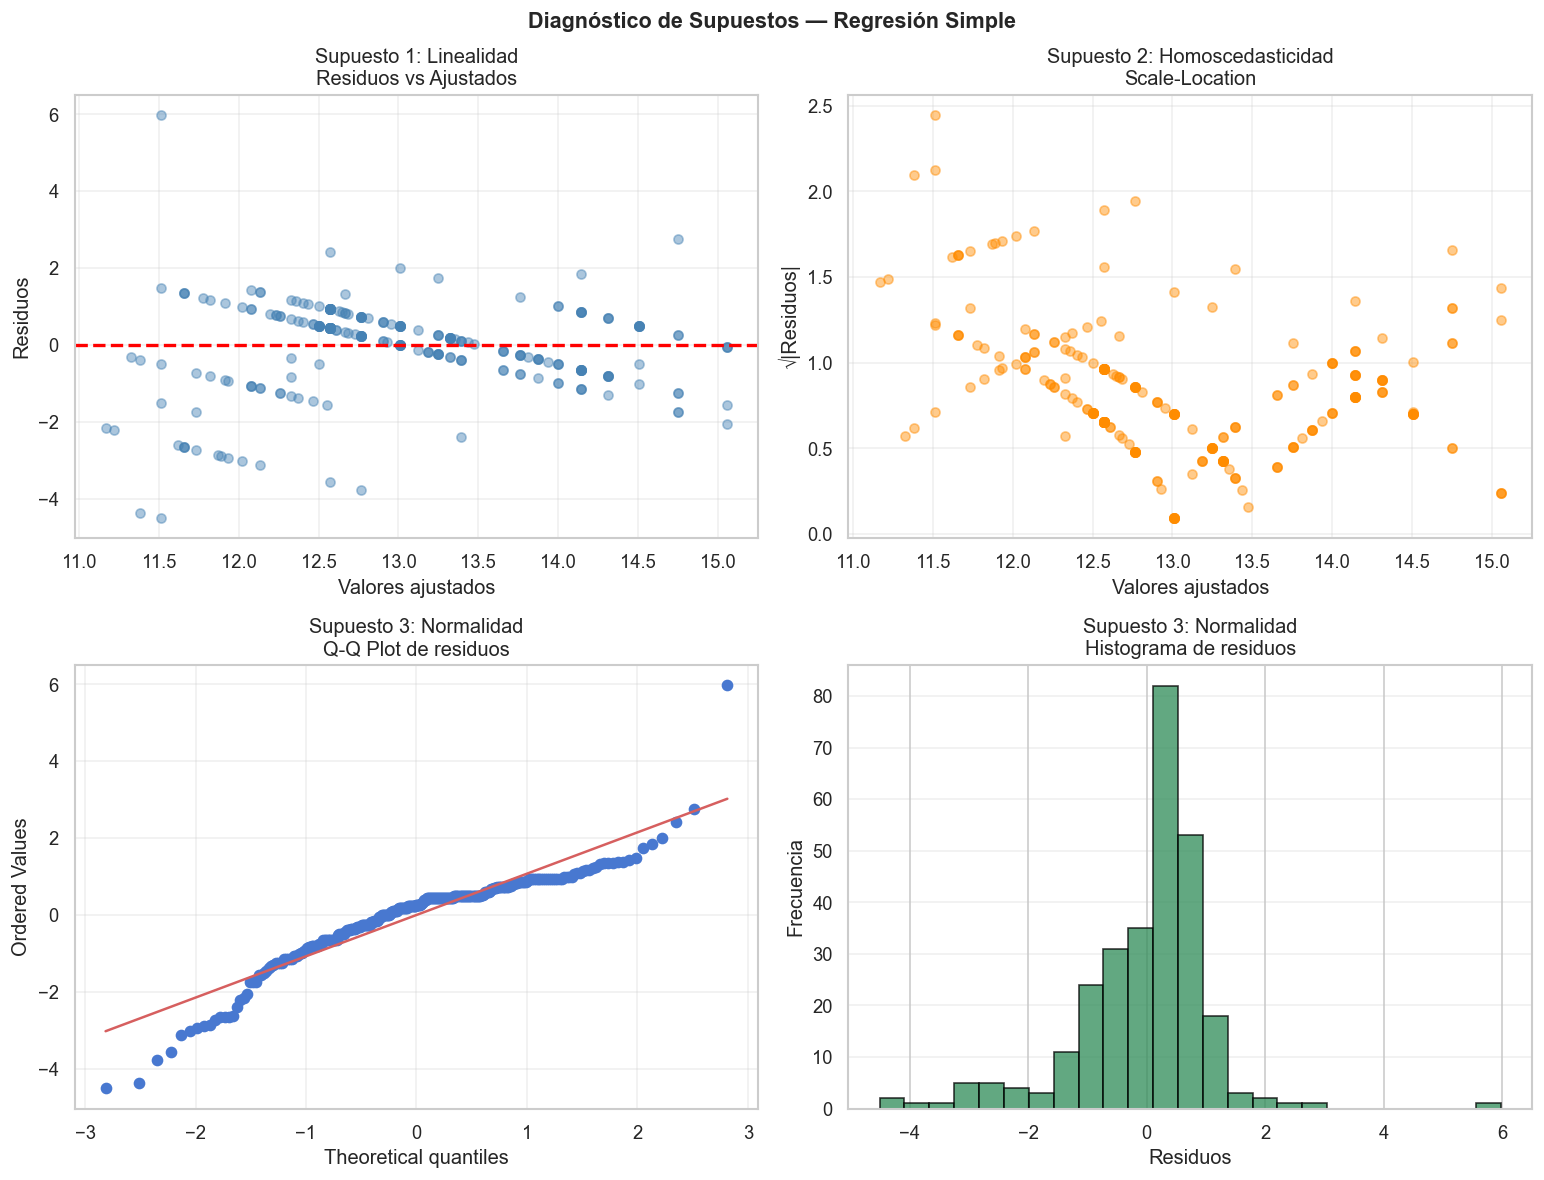

TESTS DIAGNÓSTICOS — Regresión Simple
Supuesto 2 — Homoscedasticidad:
  Breusch-Pagan:  LM = 21.4210, p = 0.0000  ✗ Heterosced. detectada

Supuesto 3 — Normalidad de residuos:
  Shapiro-Wilk:   W = 0.8918, p = 0.0000  ✗ No normal (común con n>200)

Supuesto 4 — Independencia:
  Durbin-Watson:  DW = 1.7330  ✓ Sin autocorrelación (cercano a 2)


In [ ]:
# --- 2.3 Diagnóstico de los 4 supuestos OLS (Regresión Simple) ---
residuals_s = ols_simple.resid
fitted_s = ols_simple.fittedvalues

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Supuesto 1: Linealidad — Residuos vs ajustados
axes[0, 0].scatter(fitted_s, residuals_s, alpha=0.45, s=30, color='steelblue')
axes[0, 0].axhline(0, color='red', linestyle='--', lw=2)
axes[0, 0].set_xlabel('Valores ajustados')
axes[0, 0].set_ylabel('Residuos')
axes[0, 0].set_title('Supuesto 1: Linealidad\nResiduos vs Ajustados')
axes[0, 0].grid(alpha=0.3)

# Supuesto 2: Homoscedasticidad — Scale-Location
axes[0, 1].scatter(fitted_s, np.sqrt(np.abs(residuals_s)), alpha=0.45, s=30, color='darkorange')
axes[0, 1].set_xlabel('Valores ajustados')
axes[0, 1].set_ylabel('√|Residuos|')
axes[0, 1].set_title('Supuesto 2: Homoscedasticidad\nScale-Location')
axes[0, 1].grid(alpha=0.3)

# Supuesto 3: Normalidad — Q-Q Plot
stats.probplot(residuals_s, dist='norm', plot=axes[1, 0])
axes[1, 0].set_title('Supuesto 3: Normalidad\nQ-Q Plot de residuos')
axes[1, 0].grid(alpha=0.3)

# Supuesto 3: Histograma de residuos
axes[1, 1].hist(residuals_s, bins=25, edgecolor='black', alpha=0.75, color='seagreen')
axes[1, 1].set_xlabel('Residuos')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].set_title('Supuesto 3: Normalidad\nHistograma de residuos')
axes[1, 1].grid(alpha=0.3, axis='y')

plt.suptitle('Diagnóstico de Supuestos — Regresión Simple', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../data/graficas/simple_diagnosticos_supuestos.png', dpi=150, bbox_inches='tight')
plt.show()

# Tests estadísticos
bp_lm, bp_p, _, _ = het_breuschpagan(residuals_s, X_simple)
sw_stat, sw_p = stats.shapiro(residuals_s)
dw_stat = durbin_watson(residuals_s)

print('=' * 55)
print('TESTS DIAGNÓSTICOS — Regresión Simple')
print('=' * 55)
print(f'Supuesto 2 — Homoscedasticidad:')
print(f'  Breusch-Pagan:  LM = {bp_lm:.4f}, p = {bp_p:.4f}  {"✓ Homosced." if bp_p > 0.05 else "✗ Heterosced. detectada"}')
print(f'\nSupuesto 3 — Normalidad de residuos:')
print(f'  Shapiro-Wilk:   W = {sw_stat:.4f}, p = {sw_p:.4f}  {"✓ Normal" if sw_p > 0.05 else "✗ No normal (común con n>200)"}')
print(f'\nSupuesto 4 — Independencia:')
print(f'  Durbin-Watson:  DW = {dw_stat:.4f}  {"✓ Sin autocorrelación (cercano a 2)" if 1.5 < dw_stat < 2.5 else "⚠ Posible autocorrelación"}')
print('=' * 55)

In [ ]:
# --- 2.4 Métricas del modelo simple (sobre datos completos) ---
y_pred_s = ols_simple.fittedvalues
rmse_s = np.sqrt(mean_squared_error(y, y_pred_s))
mae_s  = mean_absolute_error(y, y_pred_s)

print('MÉTRICAS — Regresión Lineal Simple (datos completos)')
print(f'  R²           : {ols_simple.rsquared:.4f}')
print(f'  R² ajustado  : {ols_simple.rsquared_adj:.4f}')
print(f'  RMSE         : {rmse_s:.4f} años')
print(f'  MAE          : {mae_s:.4f} años')
print(f'  AIC          : {ols_simple.aic:.2f}')
print(f'  F-statistic  : {ols_simple.fvalue:.2f} (p = {ols_simple.f_pvalue:.2e})')

MÉTRICAS — Regresión Lineal Simple (datos completos)
  R²           : 0.3687
  R² ajustado  : 0.3665
  RMSE         : 1.1330 años
  MAE          : 0.8129 años
  AIC          : 877.80
  F-statistic  : 164.14 (p = 6.63e-30)


---
## Fase 3 — Regresión Lineal Múltiple

**Modelo candidato**: `vida_promedio ~ β₀ + β₁·log(peso_promedio) + β₂·diferencia_sexual_peso + β₃·hipoalergenico + ε`

**Pasos**: 
1. Verificar VIF (< 10 = sin multicolinealidad grave)  
2. Ajustar OLS con `statsmodels`  
3. Eliminación *backward* si algún predictor tiene p > 0.05  
4. Diagnóstico de supuestos + partial regression plots  
5. Cook's Distance para puntos influyentes

In [ ]:
# --- 3.1 VIF — Verificar multicolinealidad entre predictores ---
features_multi = ['log_peso', 'diferencia_sexual_peso', 'hipoalergenico']
X_multi_raw = df[features_multi].copy()
X_multi_const = sm.add_constant(X_multi_raw)

vif_data = pd.DataFrame({
    'Variable': features_multi,
    'VIF': [variance_inflation_factor(X_multi_raw.values, i) for i in range(len(features_multi))]
}).sort_values('VIF', ascending=False)

display(vif_data.round(3))

max_vif = vif_data['VIF'].max()
print(f'\nVIF máximo: {max_vif:.3f}')
print('✓ Sin multicolinealidad grave (todos VIF < 10)' if max_vif < 10 else '⚠ Multicolinealidad alta detectada')

,Variable,VIF
0,log_peso,1.243
1,diferencia_sexual_peso,1.215
2,hipoalergenico,1.027



VIF máximo: 1.243
✓ Sin multicolinealidad grave (todos VIF < 10)


In [ ]:
# --- 3.2 Modelo OLS múltiple completo ---
ols_multi = sm.OLS(y, X_multi_const).fit()
print(ols_multi.summary())

                            OLS Regression Results                            
Dep. Variable:          vida_promedio   R-squared:                       0.374
Model:                            OLS   Adj. R-squared:                  0.367
Method:                 Least Squares   F-statistic:                     55.57
Date:                Tue, 21 Apr 2026   Prob (F-statistic):           3.43e-28
Time:                        16:16:56   Log-Likelihood:                -435.71
No. Observations:                 283   AIC:                             879.4
Df Residuals:                     279   BIC:                             894.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     16

In [ ]:
# --- 3.3 Eliminación backward: remover variables con p > 0.05 ---
features_current = features_multi.copy()
iteration = 0

while True:
    iteration += 1
    X_iter = sm.add_constant(df[features_current])
    model_iter = sm.OLS(y, X_iter).fit()
    pvalues = model_iter.pvalues.drop('const')
    max_p = pvalues.max()
    
    if max_p > 0.05:
        drop_var = pvalues.idxmax()
        print(f'Iteración {iteration}: eliminando "{drop_var}" (p = {max_p:.4f})')
        features_current.remove(drop_var)
    else:
        print(f'Iteración {iteration}: todos los predictores son significativos (p < 0.05)')
        break

print(f'\nPredictores finales: {features_current}')
ols_multi_final = model_iter
print(ols_multi_final.summary())

Iteración 1: eliminando "hipoalergenico" (p = 0.6023)
Iteración 2: eliminando "diferencia_sexual_peso" (p = 0.1496)
Iteración 3: todos los predictores son significativos (p < 0.05)

Predictores finales: ['log_peso']
                            OLS Regression Results                            
Dep. Variable:          vida_promedio   R-squared:                       0.369
Model:                            OLS   Adj. R-squared:                  0.366
Method:                 Least Squares   F-statistic:                     164.1
Date:                Tue, 21 Apr 2026   Prob (F-statistic):           6.63e-30
Time:                        16:17:02   Log-Likelihood:                -436.90
No. Observations:                 283   AIC:                             877.8
Df Residuals:                     281   BIC:                             885.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                    

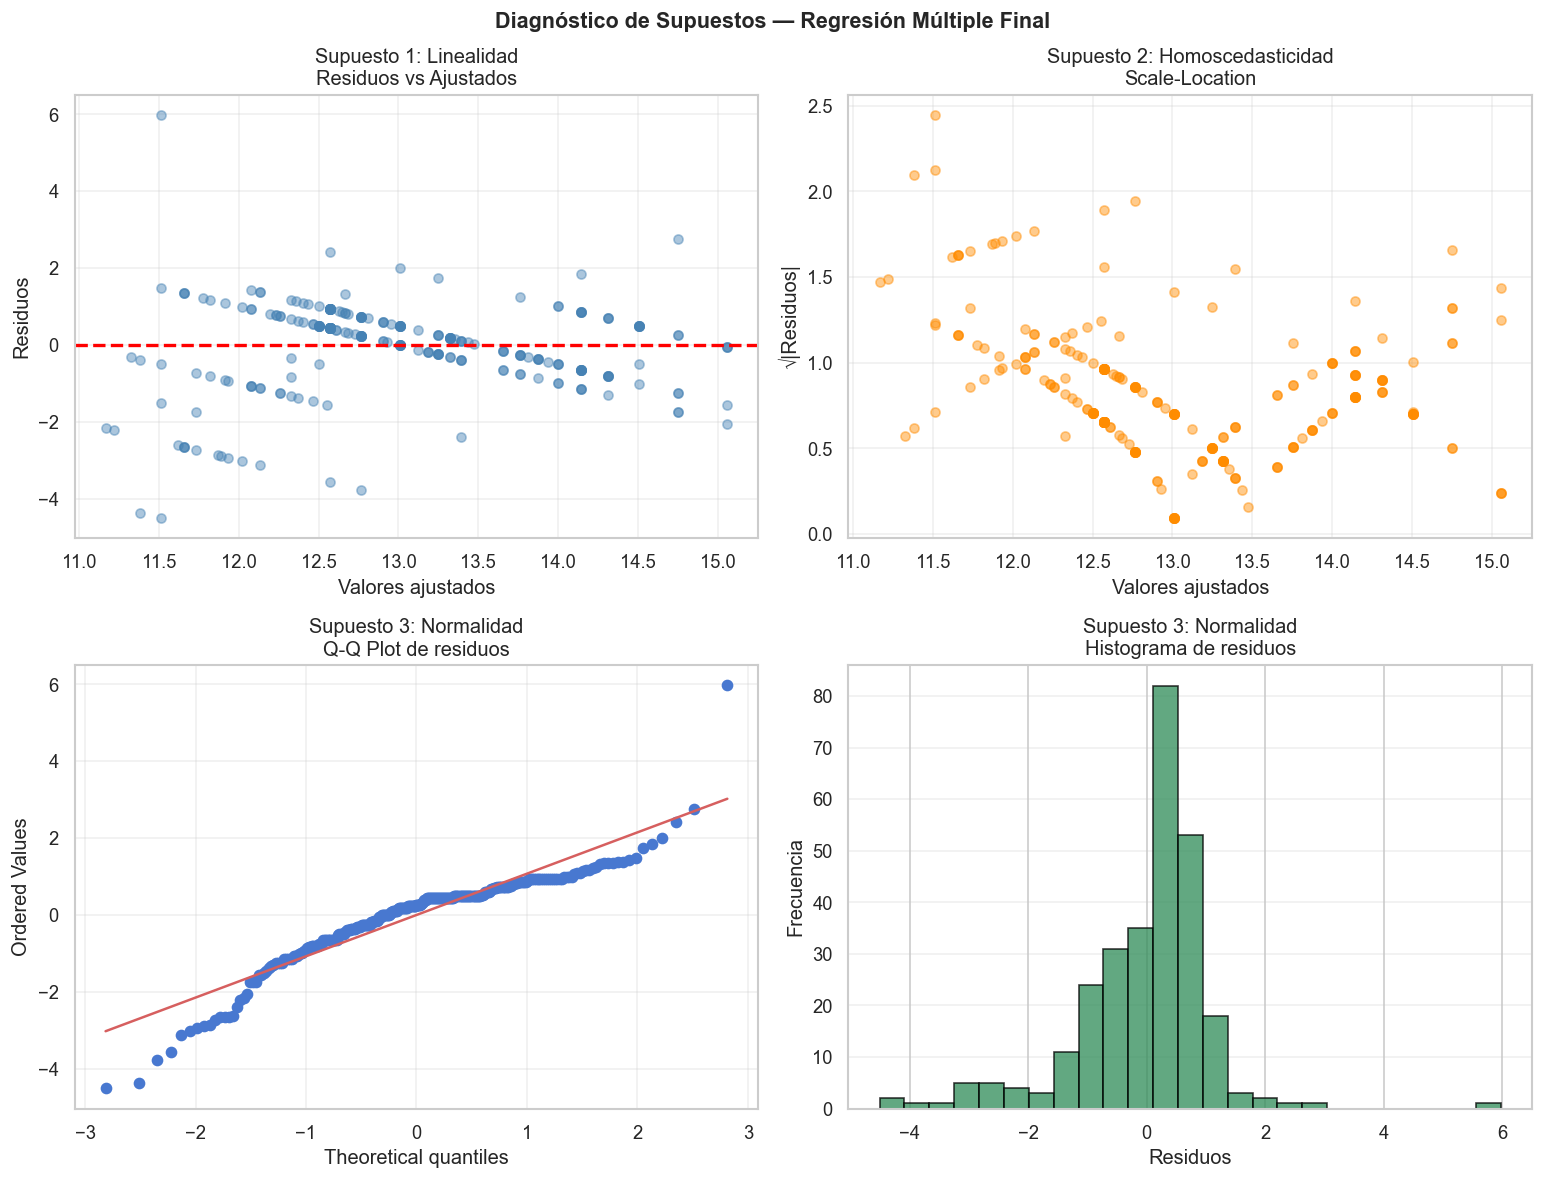

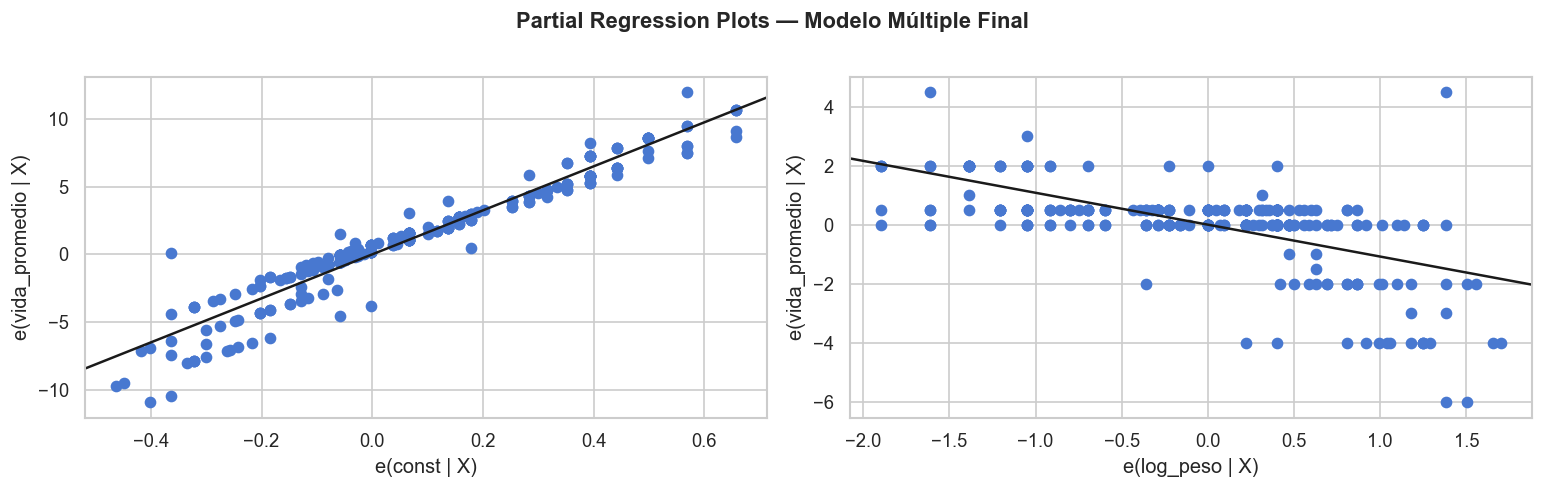

TESTS DIAGNÓSTICOS — Regresión Múltiple Final
Supuesto 2 — Breusch-Pagan:  LM = 21.4210, p = 0.0000  ✗ Heterosced. detectada
Supuesto 3 — Shapiro-Wilk:   W = 0.8918, p = 0.0000  ✗ No normal (común con n>200)
Supuesto 4 — Durbin-Watson:  DW = 1.7330  ✓ Sin autocorrelación


In [ ]:
# --- 3.4 Diagnóstico de supuestos + Partial Regression Plots (Modelo Múltiple Final) ---
residuals_m = ols_multi_final.resid
fitted_m = ols_multi_final.fittedvalues

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

axes[0, 0].scatter(fitted_m, residuals_m, alpha=0.45, s=30, color='steelblue')
axes[0, 0].axhline(0, color='red', linestyle='--', lw=2)
axes[0, 0].set_xlabel('Valores ajustados')
axes[0, 0].set_ylabel('Residuos')
axes[0, 0].set_title('Supuesto 1: Linealidad\nResiduos vs Ajustados')
axes[0, 0].grid(alpha=0.3)

axes[0, 1].scatter(fitted_m, np.sqrt(np.abs(residuals_m)), alpha=0.45, s=30, color='darkorange')
axes[0, 1].set_xlabel('Valores ajustados')
axes[0, 1].set_ylabel('√|Residuos|')
axes[0, 1].set_title('Supuesto 2: Homoscedasticidad\nScale-Location')
axes[0, 1].grid(alpha=0.3)

stats.probplot(residuals_m, dist='norm', plot=axes[1, 0])
axes[1, 0].set_title('Supuesto 3: Normalidad\nQ-Q Plot de residuos')
axes[1, 0].grid(alpha=0.3)

axes[1, 1].hist(residuals_m, bins=25, edgecolor='black', alpha=0.75, color='seagreen')
axes[1, 1].set_xlabel('Residuos')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].set_title('Supuesto 3: Normalidad\nHistograma de residuos')
axes[1, 1].grid(alpha=0.3, axis='y')

plt.suptitle('Diagnóstico de Supuestos — Regresión Múltiple Final', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../data/graficas/multiple_diagnosticos_supuestos.png', dpi=150, bbox_inches='tight')
plt.show()

# Partial Regression Plots
fig_pr = plt.figure(figsize=(13, 4 * len(features_current)))
sm.graphics.plot_partregress_grid(ols_multi_final, fig=fig_pr)
plt.suptitle('Partial Regression Plots — Modelo Múltiple Final', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/graficas/multiple_partial_regression.png', dpi=150, bbox_inches='tight')
plt.show()

# Tests
X_final_const = sm.add_constant(df[features_current])
bp_lm_m, bp_p_m, _, _ = het_breuschpagan(residuals_m, X_final_const)
sw_stat_m, sw_p_m = stats.shapiro(residuals_m)
dw_stat_m = durbin_watson(residuals_m)

print('=' * 55)
print('TESTS DIAGNÓSTICOS — Regresión Múltiple Final')
print('=' * 55)
print(f'Supuesto 2 — Breusch-Pagan:  LM = {bp_lm_m:.4f}, p = {bp_p_m:.4f}  {"✓ Homosced." if bp_p_m > 0.05 else "✗ Heterosced. detectada"}')
print(f'Supuesto 3 — Shapiro-Wilk:   W = {sw_stat_m:.4f}, p = {sw_p_m:.4f}  {"✓ Normal" if sw_p_m > 0.05 else "✗ No normal (común con n>200)"}')
print(f'Supuesto 4 — Durbin-Watson:  DW = {dw_stat_m:.4f}  {"✓ Sin autocorrelación" if 1.5 < dw_stat_m < 2.5 else "⚠ Posible autocorrelación"}')
print('=' * 55)

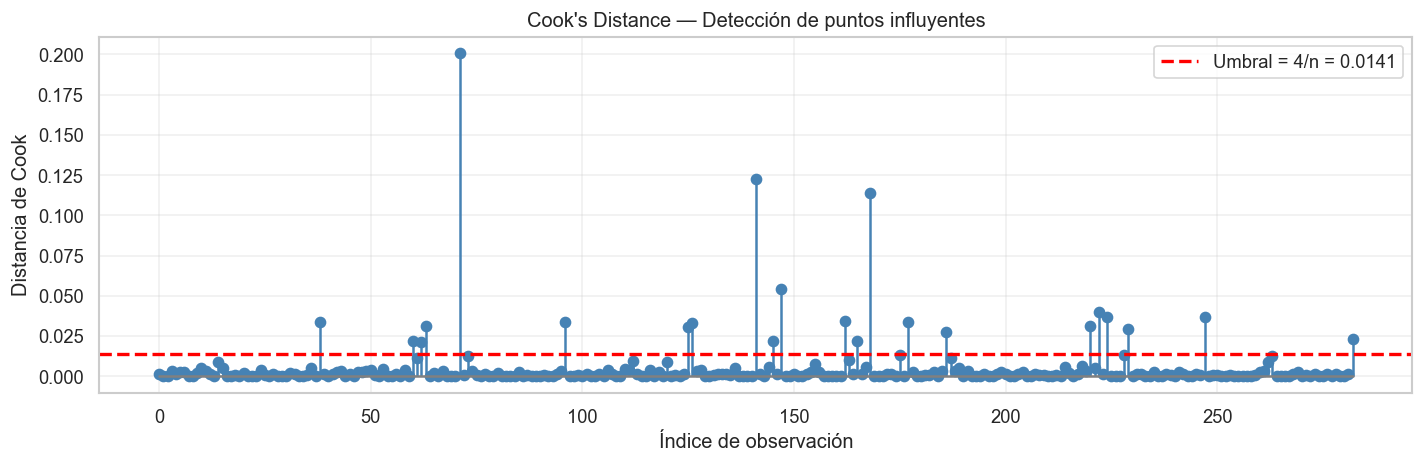

Puntos influyentes (Cook's D > 0.0141): 22
Índices: [38, 60, 62, 63, 71, 96, 125, 126, 141, 145, 147, 162, 165, 168, 177, 186, 220, 222, 224, 229, 247, 282]


,raza,vida_promedio,peso_promedio,diferencia_sexual_peso,hipoalergenico
38,Bernese Mountain Dog,9.0,70.0,0,0
60,Broholmer,9.0,30.0,0,0
62,Bulldog,9.0,25.0,0,0
63,Bullmastiff,9.0,56.5,5,0
71,Caucasian Shepherd Dog,17.5,80.0,20,0
96,Dogue de Bordeaux,9.0,70.0,0,0
125,Great Dane,9.0,54.0,0,0
126,Greater Swiss Mountain Dog,9.0,65.0,10,0
141,Irish Wolfhound,7.0,90.0,0,0
145,Japanese Chin,13.0,4.0,0,0


In [ ]:
# --- 3.5 Cook's Distance — puntos influyentes ---
influence = OLSInfluence(ols_multi_final)
cooks_d = influence.cooks_distance[0]
threshold = 4 / len(df)

fig, ax = plt.subplots(figsize=(12, 4))
ax.stem(range(len(cooks_d)), cooks_d, markerfmt='o', linefmt='steelblue', basefmt='gray')
ax.axhline(threshold, color='red', linestyle='--', lw=2, label=f'Umbral = 4/n = {threshold:.4f}')
ax.set_xlabel('Índice de observación')
ax.set_ylabel("Distancia de Cook")
ax.set_title("Cook's Distance — Detección de puntos influyentes")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../data/graficas/multiple_cooks_distance.png', dpi=150, bbox_inches='tight')
plt.show()

influential = np.where(cooks_d > threshold)[0]
print(f'Puntos influyentes (Cook\'s D > {threshold:.4f}): {len(influential)}')
if len(influential) > 0:
    print(f'Índices: {influential.tolist()}')
    display(df.iloc[influential][['raza', 'vida_promedio', 'peso_promedio', 'diferencia_sexual_peso', 'hipoalergenico']])

In [ ]:
# --- 3.6 Métricas del modelo múltiple (datos completos) ---
y_pred_m = ols_multi_final.fittedvalues
rmse_m = np.sqrt(mean_squared_error(y, y_pred_m))
mae_m  = mean_absolute_error(y, y_pred_m)

print('MÉTRICAS — Regresión Lineal Múltiple Final (datos completos)')
print(f'  Predictores finales : {features_current}')
print(f'  R²                  : {ols_multi_final.rsquared:.4f}')
print(f'  R² ajustado         : {ols_multi_final.rsquared_adj:.4f}')
print(f'  RMSE                : {rmse_m:.4f} años')
print(f'  MAE                 : {mae_m:.4f} años')
print(f'  AIC                 : {ols_multi_final.aic:.2f}')
print(f'  BIC                 : {ols_multi_final.bic:.2f}')
print(f'  F-statistic         : {ols_multi_final.fvalue:.2f} (p = {ols_multi_final.f_pvalue:.2e})')

MÉTRICAS — Regresión Lineal Múltiple Final (datos completos)
  Predictores finales : ['log_peso']
  R²                  : 0.3687
  R² ajustado         : 0.3665
  RMSE                : 1.1330 años
  MAE                 : 0.8129 años
  AIC                 : 877.80
  BIC                 : 885.09
  F-statistic         : 164.14 (p = 6.63e-30)


---
## Fase 4 — Comparación y Validación

Se comparan ambos modelos en:
1. Métricas globales (datos completos)
2. **Tres proporciones de train/test: 60/40, 70/30 y 80/20** — R² y RMSE en conjunto de prueba
3. Cross-validation 5-fold (dataset completo)
4. Ecuaciones finales explícitas

In [ ]:
# --- 4.1 Tabla comparativa global: Simple vs Múltiple ---
comparison = pd.DataFrame({
    'Métrica': ['R²', 'R² ajustado', 'RMSE (años)', 'MAE (años)', 'AIC', 'BIC'],
    'Simple': [
        round(ols_simple.rsquared, 4),
        round(ols_simple.rsquared_adj, 4),
        round(rmse_s, 4),
        round(mae_s, 4),
        round(ols_simple.aic, 2),
        round(ols_simple.bic, 2)
    ],
    'Múltiple': [
        round(ols_multi_final.rsquared, 4),
        round(ols_multi_final.rsquared_adj, 4),
        round(rmse_m, 4),
        round(mae_m, 4),
        round(ols_multi_final.aic, 2),
        round(ols_multi_final.bic, 2)
    ]
})
comparison['Diferencia'] = comparison['Múltiple'] - comparison['Simple']
print('Comparativa global (datos completos):')
display(comparison)

Comparativa global (datos completos):


,Métrica,Simple,Múltiple,Diferencia
0,R²,0.3687,0.3687,0.0
1,R² ajustado,0.3665,0.3665,0.0
2,RMSE (años),1.1330,1.1330,0.0
3,MAE (años),0.8129,0.8129,0.0
4,AIC,877.8000,877.8000,0.0
5,BIC,885.0900,885.0900,0.0


Comparativa por split train/test:


,Split (train/test),n train,n test,R² Simple (test),RMSE Simple (test),R² Múltiple (test),RMSE Múltiple (test)
0,60/40,169,114,0.3787,1.1612,0.3787,1.1612
1,70/30,198,85,0.3430,1.1605,0.3430,1.1605
2,80/20,226,57,0.3801,1.2660,0.3801,1.2660


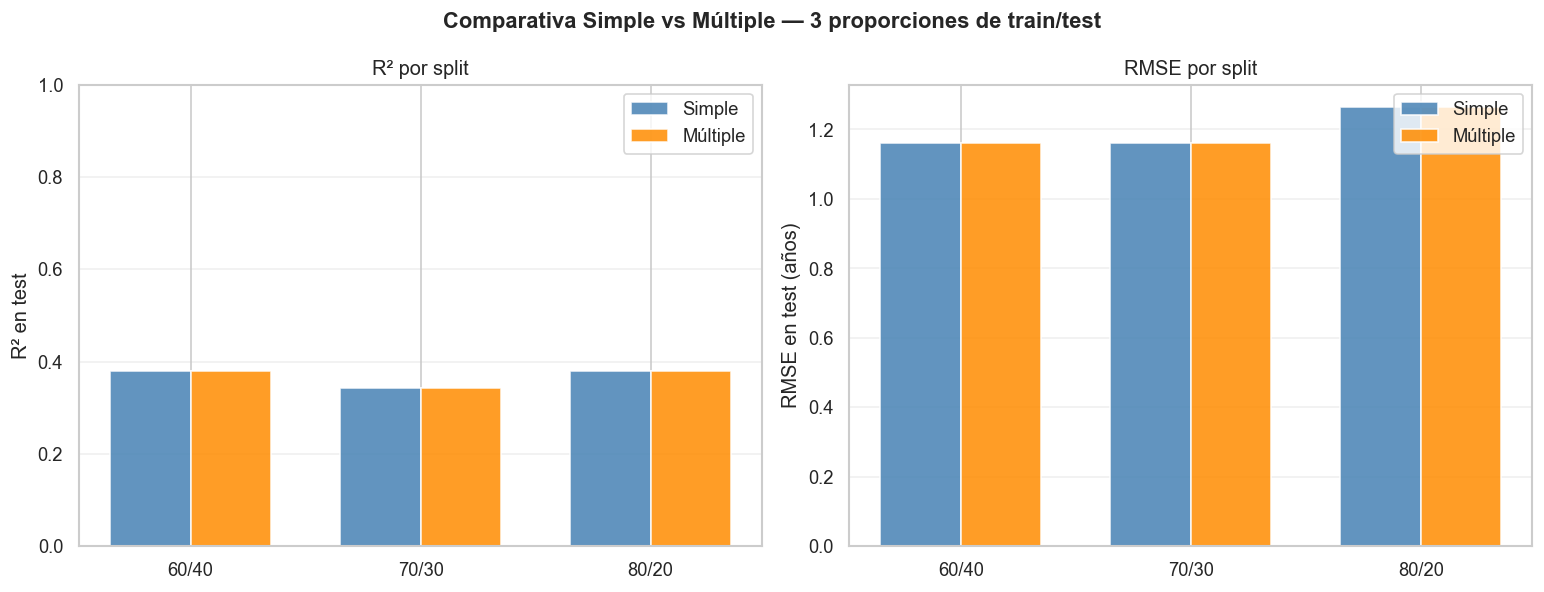

In [ ]:
# --- 4.2 Validación con 3 proporciones train/test: 60/40 · 70/30 · 80/20 ---
X_all = df[['log_peso'] + [f for f in features_current if f != 'log_peso']].copy()
X_simple_all = df[['log_peso']].copy()
splits = [0.40, 0.30, 0.20]   # fracción de test
results_splits = []

for test_size in splits:
    label = f'{int((1-test_size)*100)}/{int(test_size*100)}'

    # Split
    Xtr_s, Xte_s, ytr, yte = train_test_split(X_simple_all, y, test_size=test_size, random_state=RANDOM_STATE)
    Xtr_m, Xte_m, _, _     = train_test_split(X_all, y, test_size=test_size, random_state=RANDOM_STATE)

    # Simple OLS en train → predict test
    Xtr_s_c = sm.add_constant(Xtr_s)
    Xte_s_c = sm.add_constant(Xte_s)
    m_s = sm.OLS(ytr, Xtr_s_c).fit()
    pred_s = m_s.predict(Xte_s_c)
    r2_s_t  = r2_score(yte, pred_s)
    rmse_s_t = np.sqrt(mean_squared_error(yte, pred_s))

    # Múltiple OLS en train → predict test
    Xtr_m_c = sm.add_constant(Xtr_m)
    Xte_m_c = sm.add_constant(Xte_m)
    m_m = sm.OLS(ytr, Xtr_m_c).fit()
    pred_m = m_m.predict(Xte_m_c)
    r2_m_t  = r2_score(yte, pred_m)
    rmse_m_t = np.sqrt(mean_squared_error(yte, pred_m))

    results_splits.append({
        'Split (train/test)': label,
        'n train': len(ytr), 'n test': len(yte),
        'R² Simple (test)': round(r2_s_t, 4),
        'RMSE Simple (test)': round(rmse_s_t, 4),
        'R² Múltiple (test)': round(r2_m_t, 4),
        'RMSE Múltiple (test)': round(rmse_m_t, 4)
    })

splits_df = pd.DataFrame(results_splits)
print('Comparativa por split train/test:')
display(splits_df)

# Gráfica comparativa
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x_labels = splits_df['Split (train/test)']
x = np.arange(len(x_labels))
w = 0.35

axes[0].bar(x - w/2, splits_df['R² Simple (test)'], w, label='Simple', color='steelblue', alpha=0.85)
axes[0].bar(x + w/2, splits_df['R² Múltiple (test)'], w, label='Múltiple', color='darkorange', alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(x_labels)
axes[0].set_ylabel('R² en test')
axes[0].set_title('R² por split')
axes[0].legend(); axes[0].grid(alpha=0.3, axis='y')
axes[0].set_ylim(0, 1)

axes[1].bar(x - w/2, splits_df['RMSE Simple (test)'], w, label='Simple', color='steelblue', alpha=0.85)
axes[1].bar(x + w/2, splits_df['RMSE Múltiple (test)'], w, label='Múltiple', color='darkorange', alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(x_labels)
axes[1].set_ylabel('RMSE en test (años)')
axes[1].set_title('RMSE por split')
axes[1].legend(); axes[1].grid(alpha=0.3, axis='y')

plt.suptitle('Comparativa Simple vs Múltiple — 3 proporciones de train/test', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/graficas/comparativa_splits.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# --- 4.3 Cross-Validation 5-fold (ambos modelos, dataset completo) ---
lr = LinearRegression()

# Simple
cv_s = cross_val_score(lr, df[['log_peso']], y, cv=5, scoring='r2')
cv_s_rmse = cross_val_score(lr, df[['log_peso']], y, cv=5,
                             scoring='neg_root_mean_squared_error')

# Múltiple
cv_m = cross_val_score(lr, df[features_current], y, cv=5, scoring='r2')
cv_m_rmse = cross_val_score(lr, df[features_current], y, cv=5,
                              scoring='neg_root_mean_squared_error')

cv_results = pd.DataFrame({
    'Modelo': ['Simple', 'Múltiple'],
    'CV R² media':  [round(cv_s.mean(), 4),      round(cv_m.mean(), 4)],
    'CV R² std':    [round(cv_s.std(), 4),        round(cv_m.std(), 4)],
    'CV RMSE media':[round(-cv_s_rmse.mean(), 4), round(-cv_m_rmse.mean(), 4)],
    'CV RMSE std':  [round(cv_s_rmse.std(), 4),   round(cv_m_rmse.std(), 4)]
})

print('Cross-Validation 5-fold (dataset completo):')
display(cv_results)

Cross-Validation 5-fold (dataset completo):


,Modelo,CV R² media,CV R² std,CV RMSE media,CV RMSE std
0,Simple,0.3599,0.1124,1.1196,0.2391
1,Múltiple,0.3599,0.1124,1.1196,0.2391


In [ ]:
# --- 4.4 Ecuaciones finales explícitas con coeficientes e IC 95% ---
print('=' * 65)
print('ECUACIONES FINALES DE LOS MODELOS')
print('=' * 65)

# Simple
ci_s = ols_simple.conf_int(alpha=0.05)
b0_s, b1_s = ols_simple.params['const'], ols_simple.params['log_peso']
print(f'\n── Modelo Simple ──')
print(f'  vida_promedio = {b0_s:.4f} + ({b1_s:.4f}) · log(peso_promedio)')
print(f'\n  Coeficientes con IC 95%:')
print(f'    β₀ (constante)     = {b0_s:.4f}  [{ci_s.loc["const", 0]:.4f}, {ci_s.loc["const", 1]:.4f}]')
print(f'    β₁ (log_peso)      = {b1_s:.4f}  [{ci_s.loc["log_peso", 0]:.4f}, {ci_s.loc["log_peso", 1]:.4f}]')
print(f'\n  R² = {ols_simple.rsquared:.4f} | RMSE = {rmse_s:.4f} años | AIC = {ols_simple.aic:.2f}')

# Múltiple
ci_m = ols_multi_final.conf_int(alpha=0.05)
params_m = ols_multi_final.params
print(f'\n── Modelo Múltiple Final ──')
ec_str = ' + '.join([f'({params_m[v]:.4f})·{v}' for v in features_current])
print(f'  vida_promedio = {params_m["const"]:.4f} + {ec_str}')
print(f'\n  Coeficientes con IC 95%:')
for var in ['const'] + features_current:
    label = var if var != 'const' else 'β₀ (constante)'
    print(f'    {label:30s} = {params_m[var]:.4f}  [{ci_m.loc[var, 0]:.4f}, {ci_m.loc[var, 1]:.4f}]')
print(f'\n  R² = {ols_multi_final.rsquared:.4f} | RMSE = {rmse_m:.4f} años | AIC = {ols_multi_final.aic:.2f} | BIC = {ols_multi_final.bic:.2f}')

print('\n' + '=' * 65)
print('CONCLUSIÓN')
print('=' * 65)
delta_r2 = ols_multi_final.rsquared - ols_simple.rsquared
print(f'  El modelo múltiple mejora R² en {delta_r2:+.4f} respecto al simple.')
print(f'  AIC múltiple {"menor (mejor ajuste)" if ols_multi_final.aic < ols_simple.aic else "mayor (no justifica complejidad adicional)"} que AIC simple.')
print('=' * 65)

ECUACIONES FINALES DE LOS MODELOS

── Modelo Simple ──
  vida_promedio = 16.2455 + (-1.0805) · log(peso_promedio)

  Coeficientes con IC 95%:
    β₀ (constante)     = 16.2455  [15.7304, 16.7605]
    β₁ (log_peso)      = -1.0805  [-1.2465, -0.9145]

  R² = 0.3687 | RMSE = 1.1330 años | AIC = 877.80

── Modelo Múltiple Final ──
  vida_promedio = 16.2455 + (-1.0805)·log_peso

  Coeficientes con IC 95%:
    β₀ (constante)                 = 16.2455  [15.7304, 16.7605]
    log_peso                       = -1.0805  [-1.2465, -0.9145]

  R² = 0.3687 | RMSE = 1.1330 años | AIC = 877.80 | BIC = 885.09

CONCLUSIÓN
  El modelo múltiple mejora R² en +0.0000 respecto al simple.
  AIC múltiple mayor (no justifica complejidad adicional) que AIC simple.
